In [1]:
# Cell 1: Notebook purpose
print("This notebook demonstrates the full DVC pipeline for real-time Bitcoin data collection, preprocessing, and visualization.")


This notebook demonstrates the full DVC pipeline for real-time Bitcoin data collection, preprocessing, and visualization.


In [2]:
# Cell 2: Run the DVC pipeline (must be executed from shell)
!dvc repro


Stage 'fetch_price' didn't change, skipping                                     
Stage 'preprocess_and_plot' didn't change, skipping                             
Data and pipelines are up to date.


In [13]:
import os
import pandas as pd
from bitcoin_utils import (
    record_price,
    record_live_prices,
    preprocess,
    plot_data
)


In [15]:
record_price()
print("A single price was recorded to ensure the file is created.")


A single price was recorded to ensure the file is created.


In [17]:
# Record BTC prices for 1 minute (6 records every 10 seconds)
record_live_prices(duration_seconds=60, interval_seconds=10)


Recording Bitcoin prices every 10 seconds for 60 seconds...

✔️ Recorded price 1/6
✔️ Recorded price 2/6
✔️ Recorded price 3/6
✔️ Recorded price 4/6
✔️ Recorded price 5/6
✔️ Recorded price 6/6

✅ Finished recording.


In [19]:
df_raw = pd.read_csv("data/bitcoin_prices.csv")
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], errors='coerce')
df_raw = df_raw.dropna()
df_raw.tail(10)


,timestamp,price
0,2025-05-16 18:37:41.785580,103999
1,2025-05-18 00:25:58.095614,103224
2,2025-05-18 00:26:11.017683,103224
3,2025-05-18 00:26:21.137084,103224
4,2025-05-18 00:26:31.203705,103224
5,2025-05-18 00:26:41.297183,103224
6,2025-05-18 00:26:51.378608,103224
7,2025-05-18 00:27:01.462089,103227


In [21]:
df_cleaned = preprocess()
df_cleaned.tail(10)


,timestamp,price,price_diff,rolling_avg
0,2025-05-16 18:37:41.785580,103999,NaN,NaN
1,2025-05-18 00:25:58.095614,103224,-775.0,NaN
2,2025-05-18 00:26:11.017683,103224,0.0,NaN
3,2025-05-18 00:26:21.137084,103224,0.0,NaN
4,2025-05-18 00:26:31.203705,103224,0.0,103379.0
5,2025-05-18 00:26:41.297183,103224,0.0,103224.0
6,2025-05-18 00:26:51.378608,103224,0.0,103224.0
7,2025-05-18 00:27:01.462089,103227,3.0,103224.6


In [23]:
plot_data(df_cleaned)


✅ Plot saved to Output/bitcoin_price_plot.png


In [25]:
from pathlib import Path

files = [
    Path("data/bitcoin_prices.csv"),
    Path("data/cleaned_bitcoin.csv"),
    Path("Output/bitcoin_price_plot.png")
]

for file in files:
    print(f"Exists: {file}: {file.exists()}")


Exists: data/bitcoin_prices.csv: True
Exists: data/cleaned_bitcoin.csv: True
Exists: Output/bitcoin_price_plot.png: True


In [27]:
summary = df_cleaned[['price', 'price_diff', 'rolling_avg']].describe().round(2)
display(summary)


,price,price_diff,rolling_avg
count,8.00,7.00,4.0
mean,103321.25,-110.29,103262.9
std,273.85,293.11,77.4
min,103224.00,-775.00,103224.0
25%,103224.00,0.00,103224.0
50%,103224.00,0.00,103224.3
75%,103224.75,0.00,103263.2
max,103999.00,3.00,103379.0


In [29]:
!dvc dag

    +-------------+      
    | fetch_price |      
    +-------------+      
            *            
            *            
            *            
+---------------------+  
| preprocess_and_plot |  
+---------------------+  


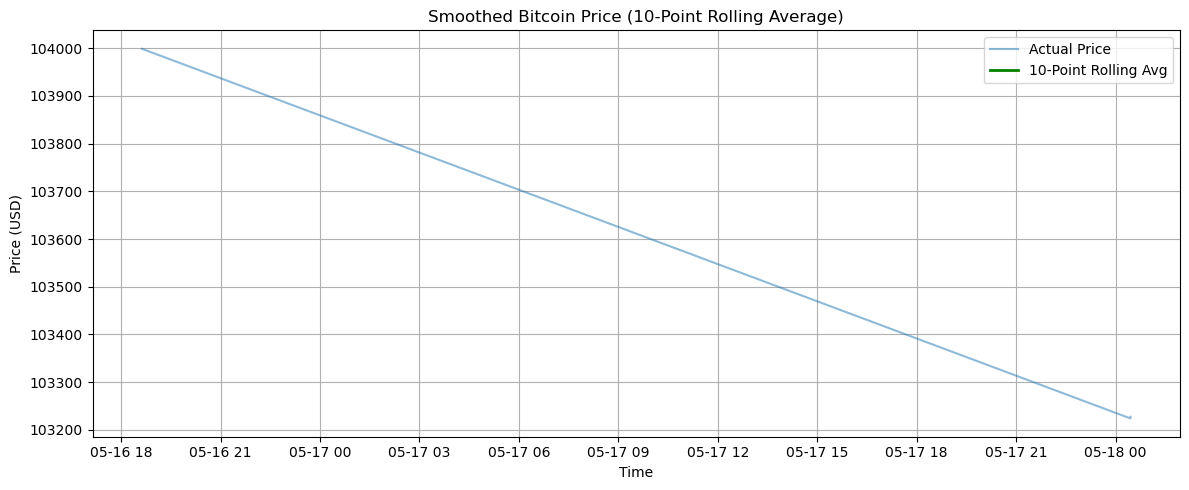

In [31]:
#Smoothing with 10-point Rolling Average
import matplotlib.pyplot as plt

df_cleaned['rolling_avg_10'] = df_cleaned['price'].rolling(window=10).mean()

plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(df_cleaned['timestamp']), df_cleaned['price'], label="Actual Price", alpha=0.5)
plt.plot(pd.to_datetime(df_cleaned['timestamp']), df_cleaned['rolling_avg_10'], label="10-Point Rolling Avg", color='green', linewidth=2)
plt.title("Smoothed Bitcoin Price (10-Point Rolling Average)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


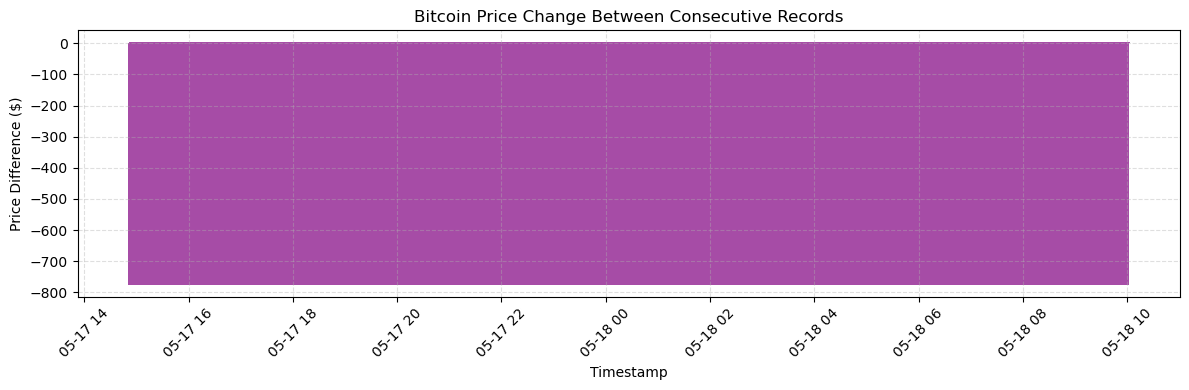

In [33]:
#Bar Plot of Price Differences
plt.figure(figsize=(12, 4))
plt.bar(pd.to_datetime(df_cleaned['timestamp']), df_cleaned['price_diff'], color='purple', alpha=0.7)
plt.title("Bitcoin Price Change Between Consecutive Records")
plt.xlabel("Timestamp")
plt.ylabel("Price Difference ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()
